## ***A Data-Driven Analysis of Tourist Satisfaction in SriLankan Destinations Using Online Review Analytics***

# Import Libraries

In [122]:
# ==============================
# Core Libraries
# ==============================
import pandas as pd
import numpy as np

# ==============================
# Visualization
# ==============================
import matplotlib.pyplot as plt
import seaborn as sns

# ==============================
# Text Processing
# ==============================
import re
import string

# ==============================
# Natural Language Processing
# ==============================
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

# ==============================
# Feature Extraction
# ==============================
from sklearn.feature_extraction.text import CountVectorizer

# ==============================
# Sentiment Analysis
# ==============================
from nltk.sentiment import SentimentIntensityAnalyzer

# ==============================
# Topic Modeling
# ==============================
from gensim import corpora
from gensim.models import LdaModel

# ==============================
# Word Cloud
# ==============================
from wordcloud import WordCloud

# ==============================
# Display Settings
# ==============================
pd.set_option('display.max_columns', None)
sns.set_style("whitegrid")

nltk.download('punkt')
nltk.download('stopwords')
nltk.download('vader_lexicon')
nltk.download('punkt_tab') # Added to resolve the LookupError

[nltk_data] Downloading package punkt to /home/asma/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /home/asma/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package vader_lexicon to
[nltk_data]     /home/asma/nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!
[nltk_data] Downloading package punkt_tab to /home/asma/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

# Basic Data Inspection and Pre processing

In [123]:
df = pd.read_csv("Reviews.csv", encoding='latin1')
df.head()

,Location_Name,Located_City,Location,Location_Type,User_ID,User_Location,User_Locale,User_Contributions,Travel_Date,Published_Date,Rating,Helpful_Votes,Title,Text
0,Arugam Bay,Arugam Bay,"Arugam Bay, Eastern Province",Beaches,User 1,"Dunsborough, Australia",en_US,8,2019-07,2019-07-31T07:53:21-04:00,5,1,Best nail spa in Arugam bay on the water!,I had a manicure here and it really was profes...
1,Arugam Bay,Arugam Bay,"Arugam Bay, Eastern Province",Beaches,User 2,"Bendigo, Australia",en_US,4,2019-06,2019-07-21T21:50:11-04:00,4,0,Best for surfing,"Overall, it is a wonderful experience. We visi..."
2,Arugam Bay,Arugam Bay,"Arugam Bay, Eastern Province",Beaches,User 3,"Melbourne, Australia",en_US,13,2019-07,2019-07-15T18:52:55-04:00,5,0,We Love Arugam Bay,"Great place to chill, swim, surf, eat, shop, h..."
3,Arugam Bay,Arugam Bay,"Arugam Bay, Eastern Province",Beaches,User 4,"Ericeira, Portugal",en_US,4,2019-06,2019-07-03T10:32:41-04:00,5,0,Sun and waves.,Good place for surf and a few stores to going ...
4,Arugam Bay,Arugam Bay,"Arugam Bay, Eastern Province",Beaches,User 5,"Pistoia, Italy",en_US,14,2019-07,2019-07-02T17:07:02-04:00,5,0,"Great swimming, surfing, great fish aznd frien...",This place is great for surfing but even if yo...


In [124]:
df.shape

(16156, 14)

In [125]:
df.columns

Index(['Location_Name', 'Located_City', 'Location', 'Location_Type', 'User_ID',
       'User_Location', 'User_Locale', 'User_Contributions', 'Travel_Date',
       'Published_Date', 'Rating', 'Helpful_Votes', 'Title', 'Text'],
      dtype='str')

In [126]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 16156 entries, 0 to 16155
Data columns (total 14 columns):
 #   Column              Non-Null Count  Dtype
---  ------              --------------  -----
 0   Location_Name       16156 non-null  str  
 1   Located_City        16156 non-null  str  
 2   Location            16156 non-null  str  
 3   Location_Type       16156 non-null  str  
 4   User_ID             16156 non-null  str  
 5   User_Location       16156 non-null  str  
 6   User_Locale         16156 non-null  str  
 7   User_Contributions  16156 non-null  int64
 8   Travel_Date         16156 non-null  str  
 9   Published_Date      16156 non-null  str  
 10  Rating              16156 non-null  int64
 11  Helpful_Votes       16156 non-null  int64
 12  Title               16156 non-null  str  
 13  Text                16156 non-null  str  
dtypes: int64(3), str(11)
memory usage: 1.7 MB


In [127]:
df.describe()

,User_Contributions,Rating,Helpful_Votes
count,16156.000000,16156.000000,16156.000000
mean,191.624845,4.167492,0.709458
std,500.100421,1.006840,3.672513
min,1.000000,1.000000,0.000000
25%,18.000000,4.000000,0.000000
50%,54.000000,4.000000,0.000000
75%,155.000000,5.000000,1.000000
max,9010.000000,5.000000,233.000000


In [128]:
df.isnull().sum()

Location_Name         0
Located_City          0
Location              0
Location_Type         0
User_ID               0
User_Location         0
User_Locale           0
User_Contributions    0
Travel_Date           0
Published_Date        0
Rating                0
Helpful_Votes         0
Title                 0
Text                  0
dtype: int64

In [129]:
df.duplicated().sum()

np.int64(0)

In [130]:
df["Rating"].value_counts()

Rating
5    7649
4    5196
3    2166
2     658
1     487
Name: count, dtype: int64

In [131]:
df["Location_Type"].value_counts()

Location_Type
Religious Sites            3017
Beaches                    2110
Farms                      1884
Nature & Wildlife Areas    1557
Museums                    1525
Historic Sites             1519
Gardens                    1354
National Parks             1205
Waterfalls                  933
Bodies of Water             839
Zoological Gardens          213
Name: count, dtype: int64

In [132]:
df["Located_City"].value_counts().head(10)

Located_City
Nuwara Eliya    2221
Anuradhapura    1758
Kandy           1480
Colombo         1171
Sigiriya         763
Habarana         754
Hikkaduwa        515
Galle            511
Jaffna           475
Ella             471
Name: count, dtype: int64

In [133]:
df["Travel_Date"] = pd.to_datetime(df["Travel_Date"], errors="coerce", utc=True)
df["Published_Date"] = pd.to_datetime(df["Published_Date"], errors="coerce", utc=True)
df.dtypes

Location_Name                         str
Located_City                          str
Location                              str
Location_Type                         str
User_ID                               str
User_Location                         str
User_Locale                           str
User_Contributions                  int64
Travel_Date           datetime64[us, UTC]
Published_Date        datetime64[us, UTC]
Rating                              int64
Helpful_Votes                       int64
Title                                 str
Text                                  str
dtype: object

In [134]:
df = df.drop(columns=["User_ID"])

In [135]:
df["review_length"] = df["Text"].apply(len)          # Creating new features
df["word_count"] = df["Text"].apply(lambda x: len(str(x).split()))
df.info()
df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 16156 entries, 0 to 16155
Data columns (total 15 columns):
 #   Column              Non-Null Count  Dtype              
---  ------              --------------  -----              
 0   Location_Name       16156 non-null  str                
 1   Located_City        16156 non-null  str                
 2   Location            16156 non-null  str                
 3   Location_Type       16156 non-null  str                
 4   User_Location       16156 non-null  str                
 5   User_Locale         16156 non-null  str                
 6   User_Contributions  16156 non-null  int64              
 7   Travel_Date         16156 non-null  datetime64[us, UTC]
 8   Published_Date      16156 non-null  datetime64[us, UTC]
 9   Rating              16156 non-null  int64              
 10  Helpful_Votes       16156 non-null  int64              
 11  Title               16156 non-null  str                
 12  Text                16156 non-null  str    

,User_Contributions,Rating,Helpful_Votes,review_length,word_count
count,16156.000000,16156.000000,16156.000000,16156.000000,16156.000000
mean,191.624845,4.167492,0.709458,380.618779,70.068705
std,500.100421,1.006840,3.672513,329.177103,60.678855
min,1.000000,1.000000,0.000000,50.000000,1.000000
25%,18.000000,4.000000,0.000000,176.000000,32.000000
50%,54.000000,4.000000,0.000000,282.000000,52.000000
75%,155.000000,5.000000,1.000000,466.000000,86.000000
max,9010.000000,5.000000,233.000000,9430.000000,1700.000000


# Exploratory Data Analysis

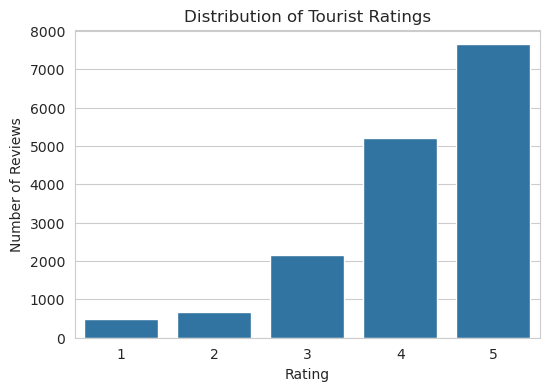

In [136]:
plt.figure(figsize=(6,4))           # This shows how satisfied tourists are overall.
sns.countplot(x="Rating", data=df)
plt.title("Distribution of Tourist Ratings")
plt.xlabel("Rating")
plt.ylabel("Number of Reviews")
plt.show()

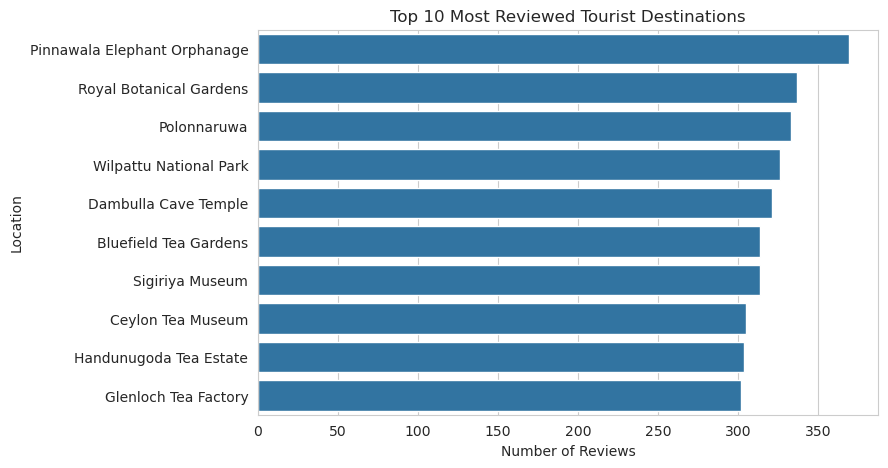

In [137]:
top_locations = df["Location_Name"].value_counts().head(10)          #This identifies popular tourist attractions.
plt.figure(figsize=(8,5))
sns.barplot(x=top_locations.values, y=top_locations.index)
plt.title("Top 10 Most Reviewed Tourist Destinations")
plt.xlabel("Number of Reviews")
plt.ylabel("Location")
plt.show()

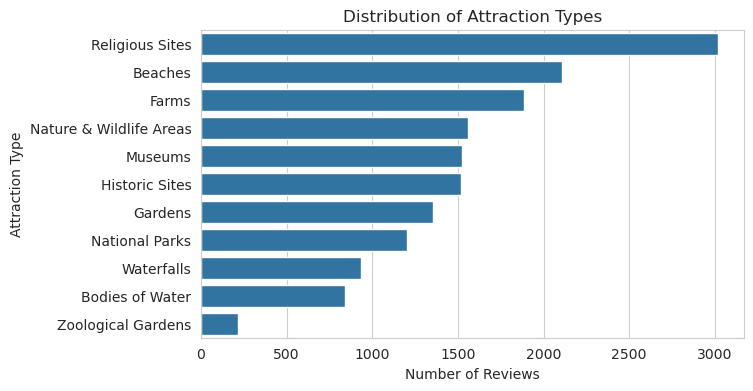

In [138]:
plt.figure(figsize=(7,4))             # This shows which types of attractions appear most frequently.
sns.countplot(y="Location_Type", data=df, order=df["Location_Type"].value_counts().index)
plt.title("Distribution of Attraction Types")
plt.xlabel("Number of Reviews")
plt.ylabel("Attraction Type")
plt.show()

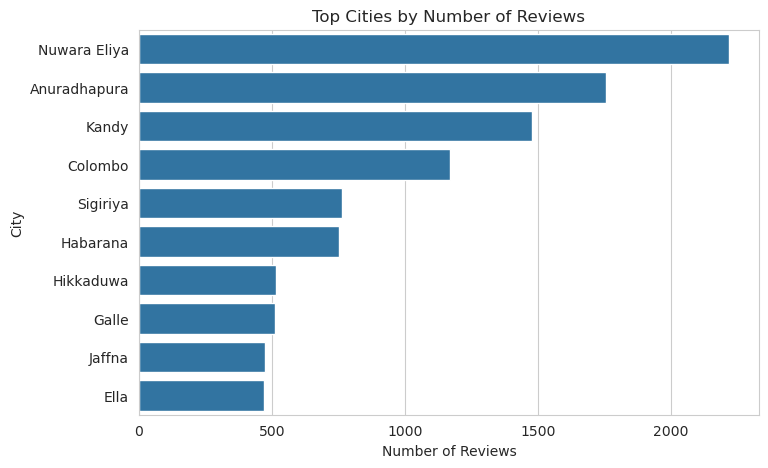

In [139]:
top_cities = df["Located_City"].value_counts().head(10)        # This identifies major tourism hubs.

plt.figure(figsize=(8,5))
sns.barplot(x=top_cities.values, y=top_cities.index)
plt.title("Top Cities by Number of Reviews")
plt.xlabel("Number of Reviews")
plt.ylabel("City")
plt.show()

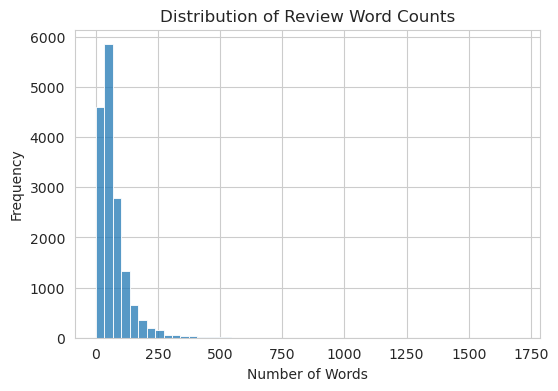

In [140]:
plt.figure(figsize=(6,4))           # This analyzes how detailed the reviews are.
sns.histplot(df["word_count"], bins=50)
plt.title("Distribution of Review Word Counts")
plt.xlabel("Number of Words")
plt.ylabel("Frequency")
plt.show()

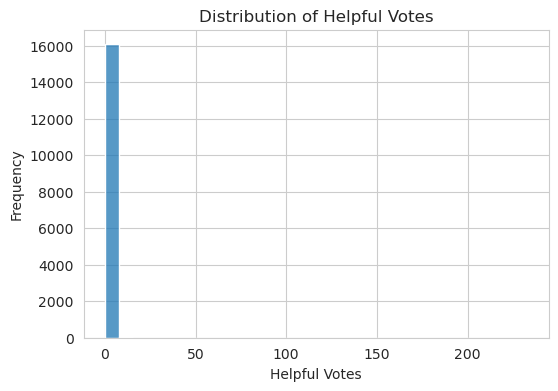

In [141]:
plt.figure(figsize=(6,4))      # This shows how often reviews are marked as helpful.
sns.histplot(df["Helpful_Votes"], bins=30)
plt.title("Distribution of Helpful Votes")
plt.xlabel("Helpful Votes")
plt.ylabel("Frequency")
plt.show()

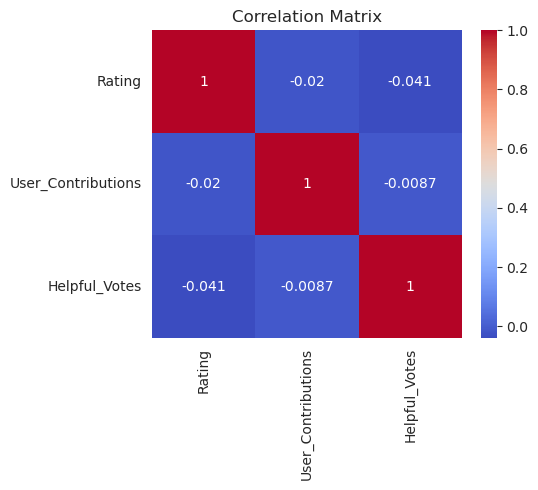

In [142]:
numeric_cols = ["Rating", "User_Contributions", "Helpful_Votes"]       # Check relationships between numeric variables.

corr_matrix = df[numeric_cols].corr()

plt.figure(figsize=(5,4))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

# Text Pre-Processing

In [143]:
# 6. Text Preprocessing

import re
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

stop_words = set(stopwords.words("english"))

def preprocess_text(text):
    if pd.isna(text):
        return ""

    text = str(text).lower()
    text = re.sub(r'http\S+|www\S+|https\S+', '', text)   # remove URLs
    text = re.sub(r'[^a-zA-Z\s]', '', text)               # remove punctuation and numbers
    tokens = word_tokenize(text)                          # tokenize
    tokens = [word for word in tokens if word not in stop_words]  # remove stopwords

    return " ".join(tokens)

df["clean_text"] = df["Text"].apply(preprocess_text)

df[["Text", "clean_text"]].head()

,Text,clean_text
0,I had a manicure here and it really was profes...,manicure really professional clean right ocean...
1,"Overall, it is a wonderful experience. We visi...",overall wonderful experience visited arugam ba...
2,"Great place to chill, swim, surf, eat, shop, h...",great place chill swim surf eat shop sunset co...
3,Good place for surf and a few stores to going ...,good place surf stores going shopping good pla...
4,This place is great for surfing but even if yo...,place great surfing even surfer wonderful time...


In [144]:
df["clean_text"].head()

0    manicure really professional clean right ocean...
1    overall wonderful experience visited arugam ba...
2    great place chill swim surf eat shop sunset co...
3    good place surf stores going shopping good pla...
4    place great surfing even surfer wonderful time...
Name: clean_text, dtype: str

In [145]:
df["clean_word_count"] = df["clean_text"].apply(lambda x: len(x.split()))
df[["word_count", "clean_word_count"]].head()

,word_count,clean_word_count
0,59,25
1,58,29
2,26,17
3,31,19
4,36,18


# Word Frequency Analysis

In [146]:
all_words = " ".join(df["clean_text"])
from collections import Counter

word_counts = Counter(all_words.split())

top_words = word_counts.most_common(20)

top_words

[('tea', 6341),
 ('see', 4970),
 ('place', 4879),
 ('visit', 4570),
 ('one', 3652),
 ('around', 3515),
 ('beach', 3471),
 ('tour', 3199),
 ('good', 3197),
 ('sri', 2988),
 ('us', 2978),
 ('nice', 2974),
 ('get', 2880),
 ('also', 2823),
 ('worth', 2783),
 ('well', 2781),
 ('time', 2730),
 ('beautiful', 2725),
 ('great', 2708),
 ('guide', 2706)]

In [147]:
freq_df = pd.DataFrame(top_words, columns=["Word", "Frequency"])
freq_df

,Word,Frequency
0,tea,6341
1,see,4970
2,place,4879
3,visit,4570
4,one,3652
5,around,3515
6,beach,3471
7,tour,3199
8,good,3197
9,sri,2988


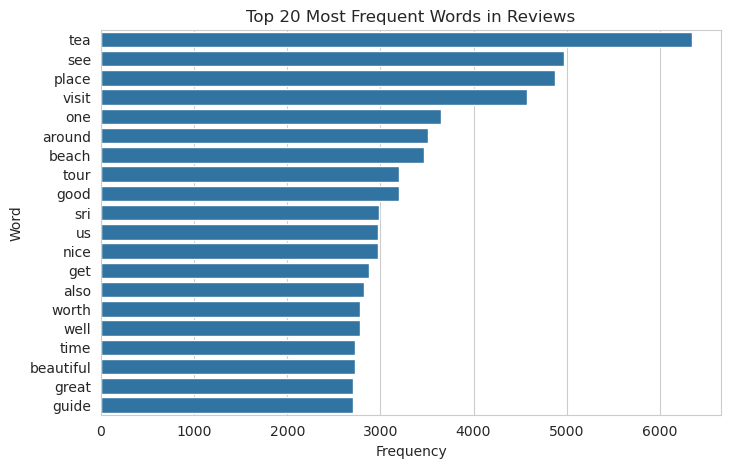

In [148]:
plt.figure(figsize=(8,5))
sns.barplot(data=freq_df, x="Frequency", y="Word")
plt.title("Top 20 Most Frequent Words in Reviews")
plt.xlabel("Frequency")
plt.ylabel("Word")
plt.show()

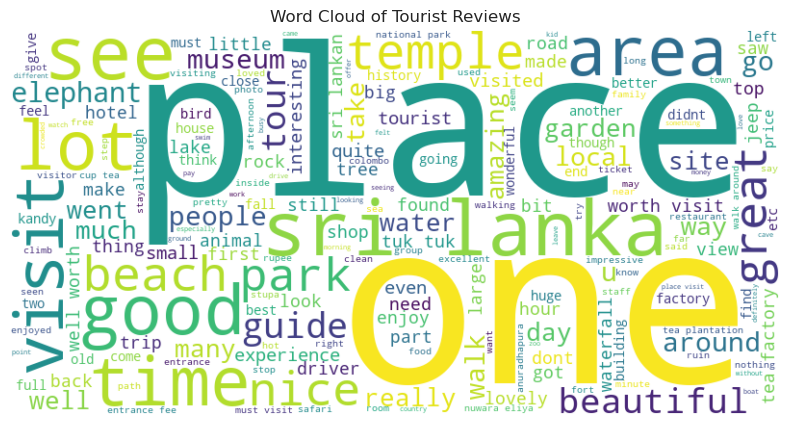

In [149]:
from wordcloud import WordCloud

wordcloud = WordCloud(width=800, height=400, background_color="white").generate(all_words)

plt.figure(figsize=(10,5))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title("Word Cloud of Tourist Reviews")
plt.show()

# Sentiment Analysis

In [150]:
from nltk.sentiment import SentimentIntensityAnalyzer

sia = SentimentIntensityAnalyzer()

df["sentiment_score"] = df["clean_text"].apply(lambda x: sia.polarity_scores(x)["compound"])
def get_sentiment(score):
    if score > 0.05:
        return "Positive"
    elif score < -0.05:
        return "Negative"
    else:
        return "Neutral"

df["sentiment"] = df["sentiment_score"].apply(get_sentiment)
df[["clean_text", "sentiment_score", "sentiment"]].head()

,clean_text,sentiment_score,sentiment
0,manicure really professional clean right ocean...,0.8393,Positive
1,overall wonderful experience visited arugam ba...,0.9565,Positive
2,great place chill swim surf eat shop sunset co...,0.9359,Positive
3,good place surf stores going shopping good pla...,0.9552,Positive
4,place great surfing even surfer wonderful time...,0.8834,Positive


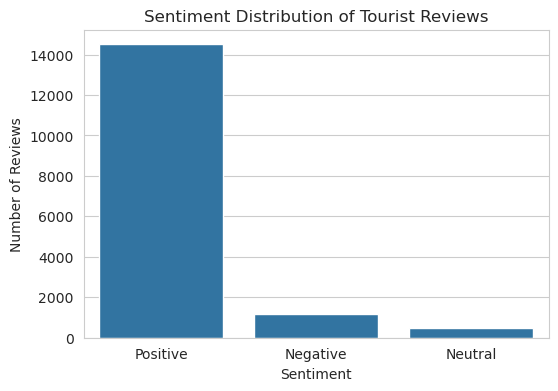

In [151]:
plt.figure(figsize=(6,4))         # This shows the overall emotional tone of tourist experiences.
sns.countplot(x="sentiment", data=df)
plt.title("Sentiment Distribution of Tourist Reviews")
plt.xlabel("Sentiment")
plt.ylabel("Number of Reviews")
plt.show()

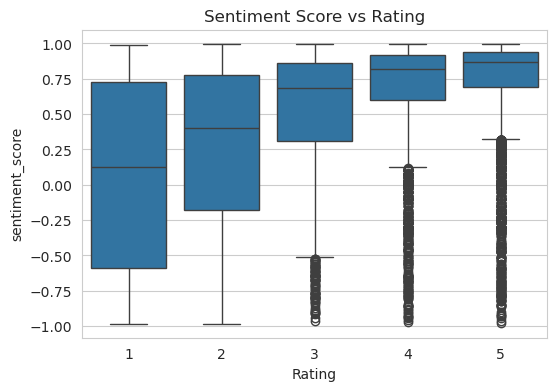

In [152]:
plt.figure(figsize=(6,4))
sns.boxplot(x="Rating", y="sentiment_score", data=df)
plt.title("Sentiment Score vs Rating")
plt.show()

# Topic Modeling (TDA)

In [153]:
texts = [text.split() for text in df["clean_text"]]

from gensim import corpora

dictionary = corpora.Dictionary(texts)
dictionary.filter_extremes(no_below=5, no_above=0.5)
corpus = [dictionary.doc2bow(text) for text in texts]

from gensim.models import LdaModel

lda_model = LdaModel(
    corpus=corpus,
    id2word=dictionary,
    num_topics=5,
    random_state=42,
    passes=10
)
topics = lda_model.print_topics(num_words=10)

for topic in topics:
    print(topic)

(0, '0.016*"elephants" + 0.015*"see" + 0.013*"park" + 0.010*"sri" + 0.009*"many" + 0.009*"one" + 0.009*"saw" + 0.008*"animals" + 0.008*"birds" + 0.008*"well"')
(1, '0.015*"get" + 0.014*"walk" + 0.011*"way" + 0.011*"take" + 0.010*"top" + 0.009*"tuk" + 0.009*"go" + 0.008*"worth" + 0.008*"around" + 0.008*"view"')
(2, '0.070*"temple" + 0.028*"visit" + 0.020*"place" + 0.016*"jaffna" + 0.015*"must" + 0.013*"one" + 0.012*"inside" + 0.011*"beautiful" + 0.011*"hindu" + 0.009*"see"')
(3, '0.016*"place" + 0.015*"beach" + 0.012*"nice" + 0.011*"people" + 0.010*"festival" + 0.009*"good" + 0.008*"beautiful" + 0.008*"clean" + 0.007*"fort" + 0.007*"great"')
(4, '0.044*"tea" + 0.023*"tour" + 0.017*"us" + 0.017*"guide" + 0.012*"factory" + 0.011*"visit" + 0.010*"interesting" + 0.010*"museum" + 0.008*"good" + 0.007*"really"')


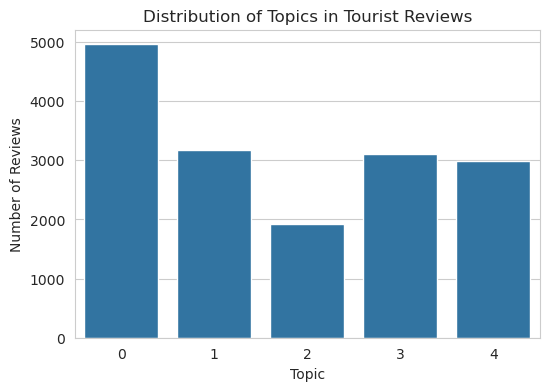

In [154]:
def get_topic(text):
    bow = dictionary.doc2bow(text.split())
    topics = lda_model.get_document_topics(bow)
    return max(topics, key=lambda x: x[1])[0]

df["topic"] = df["clean_text"].apply(get_topic)

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
sns.countplot(x="topic", data=df)
plt.title("Distribution of Topics in Tourist Reviews")
plt.xlabel("Topic")
plt.ylabel("Number of Reviews")
plt.show()

In [155]:
for idx, topic in lda_model.print_topics(num_words=10):
    print(f"Topic {idx}: {topic}")

Topic 0: 0.016*"elephants" + 0.015*"see" + 0.013*"park" + 0.010*"sri" + 0.009*"many" + 0.009*"one" + 0.009*"saw" + 0.008*"animals" + 0.008*"birds" + 0.008*"well"
Topic 1: 0.015*"get" + 0.014*"walk" + 0.011*"way" + 0.011*"take" + 0.010*"top" + 0.009*"tuk" + 0.009*"go" + 0.008*"worth" + 0.008*"around" + 0.008*"view"
Topic 2: 0.070*"temple" + 0.028*"visit" + 0.020*"place" + 0.016*"jaffna" + 0.015*"must" + 0.013*"one" + 0.012*"inside" + 0.011*"beautiful" + 0.011*"hindu" + 0.009*"see"
Topic 3: 0.016*"place" + 0.015*"beach" + 0.012*"nice" + 0.011*"people" + 0.010*"festival" + 0.009*"good" + 0.008*"beautiful" + 0.008*"clean" + 0.007*"fort" + 0.007*"great"
Topic 4: 0.044*"tea" + 0.023*"tour" + 0.017*"us" + 0.017*"guide" + 0.012*"factory" + 0.011*"visit" + 0.010*"interesting" + 0.010*"museum" + 0.008*"good" + 0.007*"really"


topic_labels = {
    0: "Wildlife Safari Tourism",
    1: "Scenic Views and Hiking",
    2: "Religious and Cultural Sites",
    3: "Beach Tourism",
    4: "Tea Plantation Tours"
}

df["topic_name"] = df["topic"].map(topic_labels)

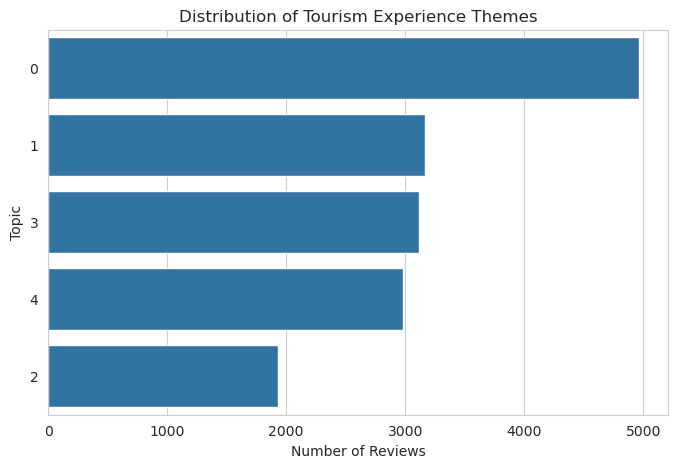

In [156]:
plt.figure(figsize=(8,5))
df.rename(columns={"topic":"topic_name"},inplace=True)
sns.countplot(y="topic_name", data=df, order=df["topic_name"].value_counts().index)

plt.title("Distribution of Tourism Experience Themes")
plt.xlabel("Number of Reviews")
plt.ylabel("Topic")
plt.show()

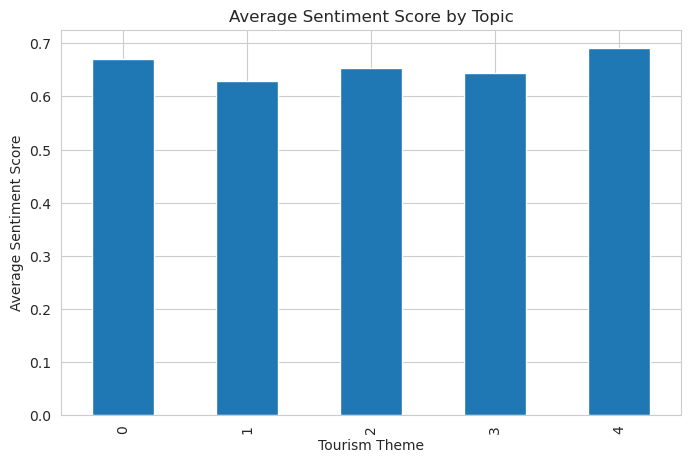

In [157]:
sentiment_topic = df.groupby("topic_name")["sentiment_score"].mean()

sentiment_topic.plot(kind="bar", figsize=(8,5))
plt.title("Average Sentiment Score by Topic")
plt.xlabel("Tourism Theme")
plt.ylabel("Average Sentiment Score")
plt.show()

In [158]:
topics = lda_model.show_topics(num_topics=5, num_words=10, formatted=False)

for topic_id, words in topics:
    print(f"\nTopic {topic_id}")
    print([word for word, prob in words])


Topic 0
['elephants', 'see', 'park', 'sri', 'many', 'one', 'saw', 'animals', 'birds', 'well']

Topic 1
['get', 'walk', 'way', 'take', 'top', 'tuk', 'go', 'worth', 'around', 'view']

Topic 2
['temple', 'visit', 'place', 'jaffna', 'must', 'one', 'inside', 'beautiful', 'hindu', 'see']

Topic 3
['place', 'beach', 'nice', 'people', 'festival', 'good', 'beautiful', 'clean', 'fort', 'great']

Topic 4
['tea', 'tour', 'us', 'guide', 'factory', 'visit', 'interesting', 'museum', 'good', 'really']


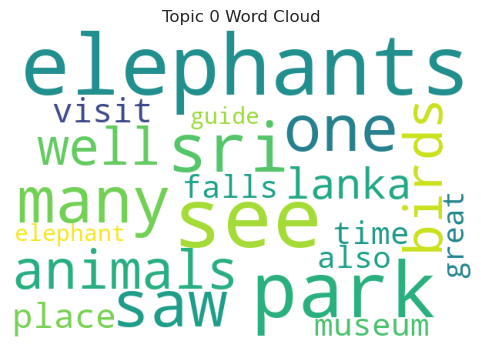

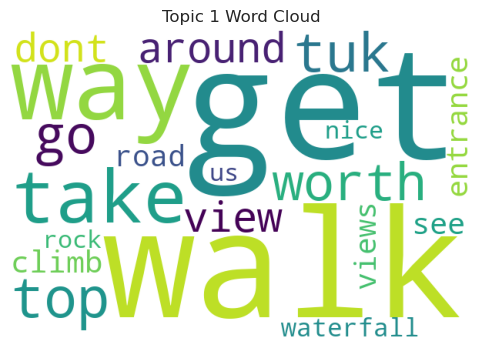

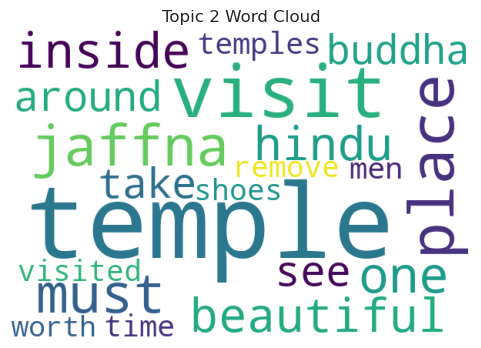

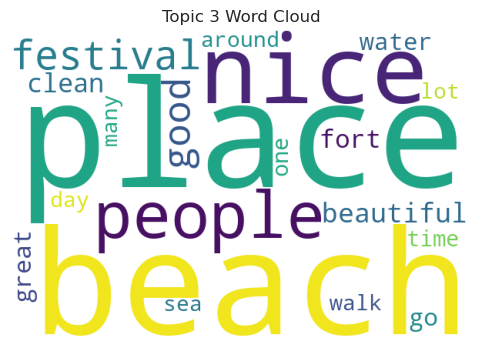

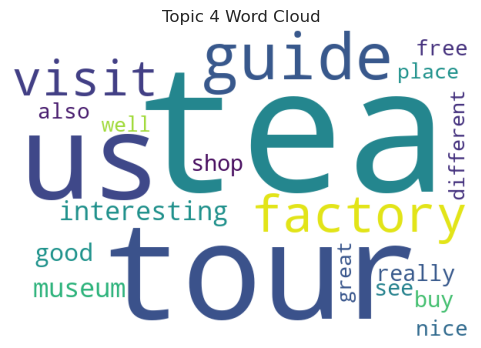

In [159]:
for topic_id, words in lda_model.show_topics(num_topics=5, num_words=20, formatted=False):

    topic_words = dict(words)

    wordcloud = WordCloud(width=600, height=400, background_color='white').generate_from_frequencies(topic_words)

    plt.figure(figsize=(6,4))
    plt.imshow(wordcloud)
    plt.axis("off")
    plt.title(f"Topic {topic_id} Word Cloud")
    plt.show()

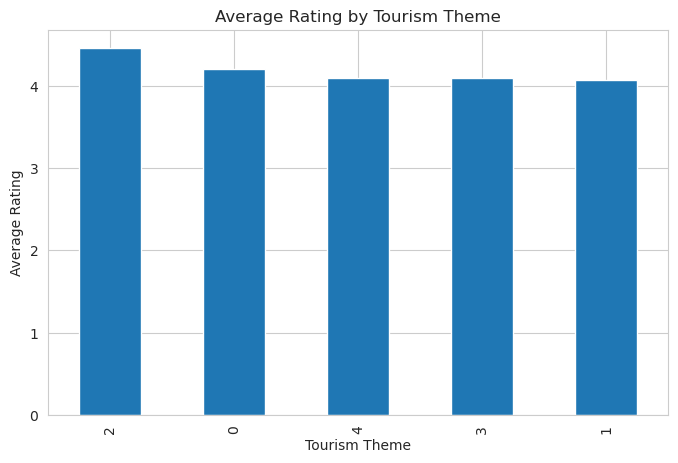

In [160]:
topic_rating = df.groupby("topic_name")["Rating"].mean().sort_values(ascending=False)

plt.figure(figsize=(8,5))
topic_rating.plot(kind="bar")

plt.title("Average Rating by Tourism Theme")
plt.xlabel("Tourism Theme")
plt.ylabel("Average Rating")
plt.show()

In [161]:
topic_city = pd.crosstab(df["Located_City"], df["topic_name"])

topic_city.head()

topic_name,0,1,2,3,4
Located_City,,,,,
Ahangama,3,2,1,0,298
Ambalangoda,6,0,0,0,71
Ampara,32,2,0,1,0
Anuradhapura,450,445,741,82,40
Arugam Bay,10,13,0,162,2


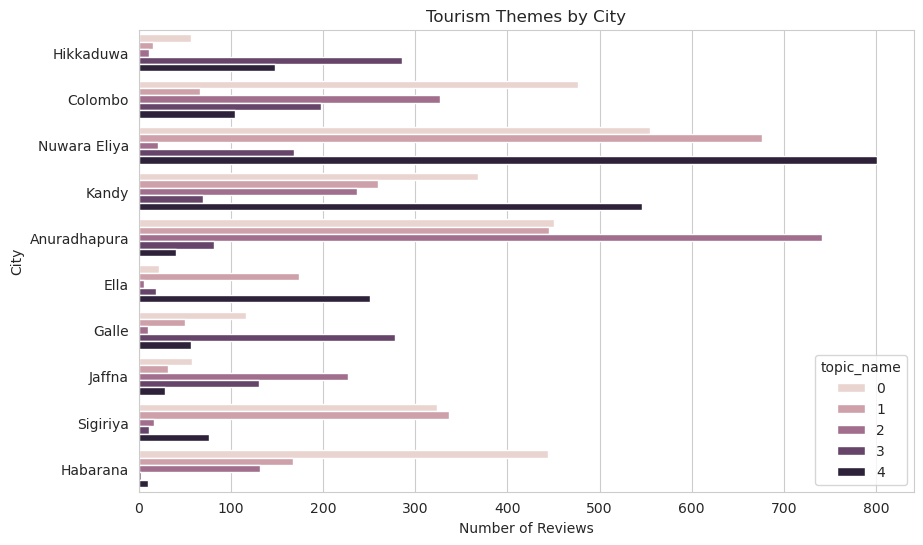

In [162]:
top_cities = df["Located_City"].value_counts().head(10).index

plt.figure(figsize=(10,6))
sns.countplot(data=df[df["Located_City"].isin(top_cities)],
              y="Located_City",
              hue="topic_name")

plt.title("Tourism Themes by City")
plt.xlabel("Number of Reviews")
plt.ylabel("City")
plt.show()

In [163]:
city_sentiment = df.groupby("Located_City")["sentiment_score"].mean().sort_values(ascending=False)

city_sentiment.head(10)

Located_City
Kalametiya      0.924144
Ahangama        0.853723
Embilipitiya    0.822677
Peradeniya      0.802066
Weligatta       0.789283
Mirissa         0.779438
Beruwala        0.776684
Bentota         0.764009
Ampara          0.760537
Koslanda        0.756226
Name: sentiment_score, dtype: float64

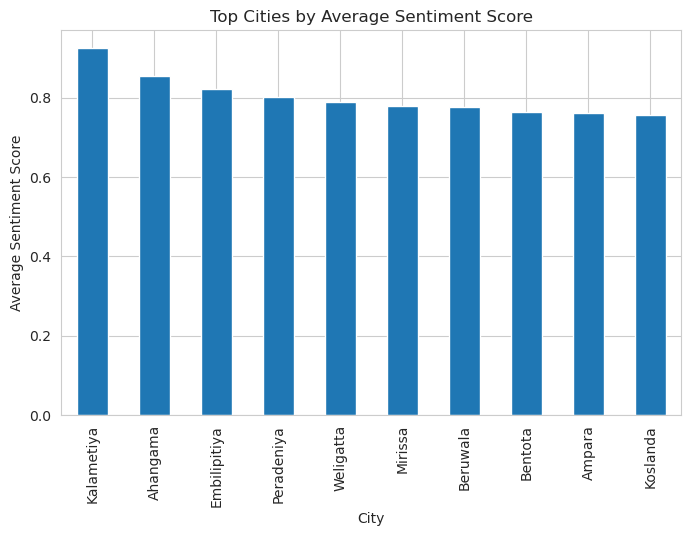

In [164]:
plt.figure(figsize=(8,5))
city_sentiment.head(10).plot(kind="bar")

plt.title("Top Cities by Average Sentiment Score")
plt.xlabel("City")
plt.ylabel("Average Sentiment Score")
plt.show()

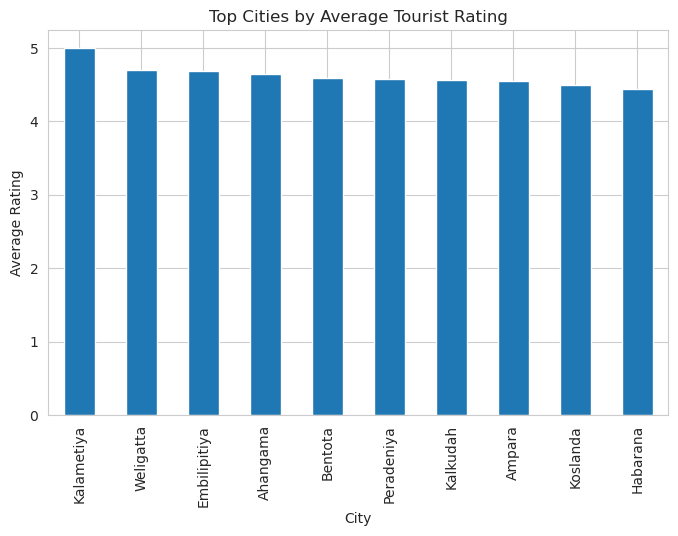

In [165]:
city_rating = df.groupby("Located_City")["Rating"].mean().sort_values(ascending=False)

plt.figure(figsize=(8,5))
city_rating.head(10).plot(kind="bar")

plt.title("Top Cities by Average Tourist Rating")
plt.xlabel("City")
plt.ylabel("Average Rating")
plt.show()

In [166]:
df.to_csv("processed_tourism_reviews.csv", index=False)

In [167]:
df["trav_month"]=df["Travel_Date"].dt.month
df["trav_year"]=df["Travel_Date"].dt.year
df["trav_day_of_week"]=df["Travel_Date"].dt.weekday
df["trav_is_weeked"] = df["trav_day_of_week"] >= 5
df["trav_is_weeked"]=df["trav_is_weeked"].astype(int)
df["trav_week_of_year"]=df["Travel_Date"].dt.isocalendar().week


In [168]:
df["pub_month"] = df["Published_Date"].dt.month
df["pub_year"] = df["Published_Date"].dt.year
df["pub_day_of_week"] = df["Published_Date"].dt.weekday
df["pub_hour"] = df["Published_Date"].dt.hour
df["pub_week_of_year"] = df["Published_Date"].dt.isocalendar().week
df["pub_is_weekend"] = df["pub_day_of_week"]>=5
df["pub_is_weekend"]=df["pub_is_weekend"].astype(int)


In [171]:
df["days_to_review"]=(df["Published_Date"] - df["Travel_Date"]).dt.days
df.to_csv("processed_tourism_reviews.csv", index=False)

In [170]:
df.head()

,Location_Name,Located_City,Location,Location_Type,User_Location,User_Locale,User_Contributions,Travel_Date,Published_Date,Rating,Helpful_Votes,Title,Text,review_length,word_count,clean_text,clean_word_count,sentiment_score,sentiment,topic_name,trav_month,trav_year,trav_day_of_week,trav_is_weeked,trav_week_of_year,pub_month,pub_year,pub_day_of_week,pub_hour,pub_week_of_year,pub_is_weekend,days_to_review
0,Arugam Bay,Arugam Bay,"Arugam Bay, Eastern Province",Beaches,"Dunsborough, Australia",en_US,8,2019-07-01 00:00:00+00:00,2019-07-31 11:53:21+00:00,5,1,Best nail spa in Arugam bay on the water!,I had a manicure here and it really was profes...,320,59,manicure really professional clean right ocean...,25,0.8393,Positive,3,7,2019,0,0,27,7,2019,2,11,31,0,30
1,Arugam Bay,Arugam Bay,"Arugam Bay, Eastern Province",Beaches,"Bendigo, Australia",en_US,4,2019-06-01 00:00:00+00:00,2019-07-22 01:50:11+00:00,4,0,Best for surfing,"Overall, it is a wonderful experience. We visi...",312,58,overall wonderful experience visited arugam ba...,29,0.9565,Positive,3,6,2019,5,1,22,7,2019,0,1,30,0,51
2,Arugam Bay,Arugam Bay,"Arugam Bay, Eastern Province",Beaches,"Melbourne, Australia",en_US,13,2019-07-01 00:00:00+00:00,2019-07-15 22:52:55+00:00,5,0,We Love Arugam Bay,"Great place to chill, swim, surf, eat, shop, h...",156,26,great place chill swim surf eat shop sunset co...,17,0.9359,Positive,3,7,2019,0,0,27,7,2019,0,22,29,0,14
3,Arugam Bay,Arugam Bay,"Arugam Bay, Eastern Province",Beaches,"Ericeira, Portugal",en_US,4,2019-06-01 00:00:00+00:00,2019-07-03 14:32:41+00:00,5,0,Sun and waves.,Good place for surf and a few stores to going ...,170,31,good place surf stores going shopping good pla...,19,0.9552,Positive,3,6,2019,5,1,22,7,2019,2,14,27,0,32
4,Arugam Bay,Arugam Bay,"Arugam Bay, Eastern Province",Beaches,"Pistoia, Italy",en_US,14,2019-07-01 00:00:00+00:00,2019-07-02 21:07:02+00:00,5,0,"Great swimming, surfing, great fish aznd frien...",This place is great for surfing but even if yo...,206,36,place great surfing even surfer wonderful time...,18,0.8834,Positive,3,7,2019,0,0,27,7,2019,1,21,27,0,1
